In [1]:
# 标准库
import os
import sys
import time
import sqlite3
import traceback
import subprocess
from datetime import datetime, timedelta
from collections import Counter
# 第三方库
import pandas as pd
import schedule
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from textblob import TextBlob
import logging
import torch
from tqdm import tqdm
import subprocess
from collections import Counter
# 从模块导入
from google_play_scraper import reviews, Sort
from sqlalchemy import create_engine, text
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification


配置文件 config.py

In [12]:
# 配置类
class Config:
    # 数据库配置
    DATABASE_PATH = "chatgpt_reviews.db"
    
    # 分析配置
    MIN_REVIEW_LENGTH = 5
    SENTIMENT_THRESHOLD_POSITIVE = 0.1
    SENTIMENT_THRESHOLD_NEGATIVE = -0.1
    
    # 可视化配置
    PLOT_STYLE = "seaborn-v0_8"
    COLOR_POSITIVE = "#99ff99"
    COLOR_NEUTRAL = "#66b3ff"
    COLOR_NEGATIVE = "#ff9999"
    
    # 关键词分析
    STOP_WORDS = {
        'the', 'and', 'is', 'in', 'it', 'to', 'of', 'for', 'with', 'on', 
        'this', 'that', 'are', 'as', 'be', 'but', 'by', 'from', 'has', 
        'have', 'was', 'were', 'will', 'would', 'you', 'your', 'app', 
        'chatgpt', 'openai', 'gpt', 'chat', 'just', 'like', 'get', 'can'
    }
    
    # 图表尺寸
    FIGURE_SIZE_LARGE = (15, 10)
    FIGURE_SIZE_MEDIUM = (12, 8)
    FIGURE_SIZE_SMALL = (10, 6)

print("✅ 配置类定义完成")

✅ 配置类定义完成


数据库管理模块 database/database_manager.py

In [13]:
# 数据库管理类
class DatabaseManager:
    def __init__(self, db_path=None):
        self.db_path = db_path or Config.DATABASE_PATH
    
    def load_reviews_data(self, limit=None):
        """
        从数据库加载评论数据
        """
        try:
            conn = sqlite3.connect(self.db_path)
            
            query = """
            SELECT reviewId, userName, content, score, thumbsUpCount, at, 
                   reviewCreatedVersion, appVersion 
            FROM reviews
            """
            
            if limit:
                query += f" LIMIT {limit}"
            
            df = pd.read_sql_query(query, conn)
            conn.close()
            
            print(f"✅ 成功从数据库加载 {len(df)} 条评论")
            return df
            
        except Exception as e:
            print(f"❌ 数据加载失败: {e}")
            return pd.DataFrame()
    
    def get_database_stats(self):
        """
        获取数据库统计信息
        """
        try:
            conn = sqlite3.connect(self.db_path)
            
            stats_query = """
            SELECT 
                COUNT(*) as total_reviews,
                AVG(score) as avg_score,
                MIN(at) as earliest_review,
                MAX(at) as latest_review,
                COUNT(DISTINCT appVersion) as unique_versions
            FROM reviews
            """
            
            stats = pd.read_sql_query(stats_query, conn)
            conn.close()
            
            return {
                'total_reviews': stats['total_reviews'][0],
                'avg_score': round(stats['avg_score'][0], 2),
                'earliest_review': stats['earliest_review'][0],
                'latest_review': stats['latest_review'][0],
                'unique_versions': stats['unique_versions'][0]
            }
            
        except Exception as e:
            print(f"❌ 统计信息获取失败: {e}")
            return {}

print("✅ 数据库管理类定义完成")

✅ 数据库管理类定义完成


文本处理模块 analysis/text_processor.py

In [14]:
# 文本处理类
class TextProcessor:
    def __init__(self):
        self.stop_words = Config.STOP_WORDS
    
    def clean_text(self, text):
        """
        清理文本数据
        """
        if pd.isna(text):
            return ""
        
        text = str(text)
        
        # 清理步骤
        text = text.lower()
        text = re.sub(r'http\S+', '', text)  # 移除URL
        text = re.sub(r'[^\w\s]', ' ', text)  # 移除标点符号
        text = re.sub(r'\d+', '', text)  # 移除数字
        text = re.sub(r'\s+', ' ', text)  # 移除多余空格
        text = text.strip()
        
        return text
    
    def preprocess_dataframe(self, df):
        """
        预处理整个DataFrame
        """
        if df.empty:
            return df
        
        # 创建副本避免修改原数据
        processed_df = df.copy()
        
        # 清理文本内容
        processed_df['cleaned_content'] = processed_df['content'].apply(self.clean_text)
        
        # 过滤太短的评论
        initial_count = len(processed_df)
        processed_df = processed_df[processed_df['cleaned_content'].str.len() > Config.MIN_REVIEW_LENGTH]
        filtered_count = initial_count - len(processed_df)
        
        print(f"📝 文本预处理完成: 过滤了 {filtered_count} 条过短评论")
        
        return processed_df

print("✅ 文本处理类定义完成")

✅ 文本处理类定义完成


 情感分析核心模块 analysis/sentiment_analyzer.py

In [5]:
class SentimentAnalyzer:
    def __init__(self):
        self.results = None
    
    def analyze_sentiment_textblob(self, text):
        """
        使用TextBlob进行情感分析
        """
        try:
            analysis = TextBlob(text)
            polarity = analysis.sentiment.polarity
            subjectivity = analysis.sentiment.subjectivity
            
            # 基于阈值分类情感
            if polarity > Config.SENTIMENT_THRESHOLD_POSITIVE:
                sentiment_label = 'positive'
            elif polarity < Config.SENTIMENT_THRESHOLD_NEGATIVE:
                sentiment_label = 'negative'
            else:
                sentiment_label = 'neutral'
            
            return {
                'polarity': polarity,
                'subjectivity': subjectivity,
                'sentiment_label': sentiment_label
            }
        except Exception:
            return {'polarity': 0, 'subjectivity': 0, 'sentiment_label': 'neutral'}
    
    def analyze_sentiment_based_on_score(self, score):
        """
        基于评分的情感分类
        """
        if score >= 4:
            return 'positive'
        elif score <= 2:
            return 'negative'
        else:
            return 'neutral'
    
    def perform_sentiment_analysis(self, df):
        """
        执行完整的情感分析
        """
        if df.empty:
            print("❌ 没有数据可分析")
            return pd.DataFrame()
        
        print("🔄 开始情感分析...")
        
        # TextBlob情感分析
        sentiment_results = df['cleaned_content'].apply(self.analyze_sentiment_textblob)
        
        # 展开情感分析结果
        sentiment_df = pd.json_normalize(sentiment_results)
        result_df = pd.concat([df, sentiment_df], axis=1)
        
        # 基于评分的分类
        result_df['score_sentiment'] = result_df['score'].apply(self.analyze_sentiment_based_on_score)
        
        # 计算情感一致性
        sentiment_agreement = (result_df['sentiment_label'] == result_df['score_sentiment']).mean()
        print(f"🤝 情感一致性: {sentiment_agreement:.1%}")
        
        self.results = result_df
        print("✅ 情感分析完成!")
        
        return result_df
    
    def get_sentiment_summary(self):
        """
        获取情感分析摘要
        """
        if self.results is None:
            return {}
        
        summary = {
            'total_reviews': len(self.results),
            'avg_score': self.results['score'].mean(),
            'avg_polarity': self.results['polarity'].mean(),
            'avg_subjectivity': self.results['subjectivity'].mean(),
            'positive_count': len(self.results[self.results['sentiment_label'] == 'positive']),
            'neutral_count': len(self.results[self.results['sentiment_label'] == 'neutral']),
            'negative_count': len(self.results[self.results['sentiment_label'] == 'negative']),
        }
        
        # 计算百分比
        summary['positive_percent'] = summary['positive_count'] / summary['total_reviews']
        summary['neutral_percent'] = summary['neutral_count'] / summary['total_reviews']
        summary['negative_percent'] = summary['negative_count'] / summary['total_reviews']
        
        return summary
    
    def get_extreme_reviews(self, n=5):
        """
        获取最积极和最消极的评论
        """
        if self.results is None:
            return {}, {}
        
        most_positive = self.results.nlargest(n, 'polarity')[
            ['content', 'score', 'polarity', 'sentiment_label']
        ]
        most_negative = self.results.nsmallest(n, 'polarity')[
            ['content', 'score', 'polarity', 'sentiment_label']
        ]
        
        return most_positive, most_negative

In [15]:
# 情感分析类
class SentimentAnalyzer:
    def __init__(self):
        self.results = None
    
    def analyze_sentiment_textblob(self, text):
        """
        使用TextBlob进行情感分析
        """
        try:
            analysis = TextBlob(text)
            polarity = analysis.sentiment.polarity
            subjectivity = analysis.sentiment.subjectivity
            
            # 基于阈值分类情感
            if polarity > Config.SENTIMENT_THRESHOLD_POSITIVE:
                sentiment_label = 'positive'
            elif polarity < Config.SENTIMENT_THRESHOLD_NEGATIVE:
                sentiment_label = 'negative'
            else:
                sentiment_label = 'neutral'
            
            return {
                'polarity': polarity,
                'subjectivity': subjectivity,
                'sentiment_label': sentiment_label
            }
        except Exception:
            return {'polarity': 0, 'subjectivity': 0, 'sentiment_label': 'neutral'}
    
    def analyze_sentiment_based_on_score(self, score):
        """
        基于评分的情感分类
        """
        if score >= 4:
            return 'positive'
        elif score <= 2:
            return 'negative'
        else:
            return 'neutral'
    
    def perform_sentiment_analysis(self, df):
        """
        执行完整的情感分析
        """
        if df.empty:
            print("❌ 没有数据可分析")
            return pd.DataFrame()
        
        print("🔄 开始情感分析...")
        
        # TextBlob情感分析
        sentiment_results = df['cleaned_content'].apply(self.analyze_sentiment_textblob)
        
        # 展开情感分析结果
        sentiment_df = pd.json_normalize(sentiment_results)
        result_df = pd.concat([df, sentiment_df], axis=1)
        
        # 基于评分的分类
        result_df['score_sentiment'] = result_df['score'].apply(self.analyze_sentiment_based_on_score)
        
        # 计算情感一致性
        sentiment_agreement = (result_df['sentiment_label'] == result_df['score_sentiment']).mean()
        print(f"🤝 情感一致性: {sentiment_agreement:.1%}")
        
        self.results = result_df
        print("✅ 情感分析完成!")
        
        return result_df
    
    def get_sentiment_summary(self):
        """
        获取情感分析摘要
        """
        if self.results is None:
            return {}
        
        summary = {
            'total_reviews': len(self.results),
            'avg_score': self.results['score'].mean(),
            'avg_polarity': self.results['polarity'].mean(),
            'avg_subjectivity': self.results['subjectivity'].mean(),
            'positive_count': len(self.results[self.results['sentiment_label'] == 'positive']),
            'neutral_count': len(self.results[self.results['sentiment_label'] == 'neutral']),
            'negative_count': len(self.results[self.results['sentiment_label'] == 'negative']),
        }
        
        # 计算百分比
        summary['positive_percent'] = summary['positive_count'] / summary['total_reviews']
        summary['neutral_percent'] = summary['neutral_count'] / summary['total_reviews']
        summary['negative_percent'] = summary['negative_count'] / summary['total_reviews']
        
        return summary
    
    def get_extreme_reviews(self, n=5):
        """
        获取最积极和最消极的评论
        """
        if self.results is None:
            return pd.DataFrame(), pd.DataFrame()
        
        most_positive = self.results.nlargest(n, 'polarity')[
            ['content', 'score', 'polarity', 'sentiment_label']
        ]
        most_negative = self.results.nsmallest(n, 'polarity')[
            ['content', 'score', 'polarity', 'sentiment_label']
        ]
        
        return most_positive, most_negative

print("✅ 情感分析类定义完成")

✅ 情感分析类定义完成


可视化模块 visualization/plot_generator.py

In [19]:
# Visualization Class
class PlotGenerator:
    def __init__(self):
        plt.style.use(Config.PLOT_STYLE)
    
    def plot_sentiment_distribution(self, df, save_path=None):
        """Plot sentiment distribution"""
        fig, axes = plt.subplots(2, 2, figsize=Config.FIGURE_SIZE_LARGE)
        
        # 1. Rating distribution
        score_counts = df['score'].value_counts().sort_index()
        axes[0,0].bar(score_counts.index, score_counts.values, 
                     color='skyblue', alpha=0.7)
        axes[0,0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
        axes[0,0].set_xlabel('Rating Score')
        axes[0,0].set_ylabel('Count')
        for i, v in enumerate(score_counts.values):
            axes[0,0].text(score_counts.index[i], v, str(v), ha='center', va='bottom')
        
        # 2. TextBlob sentiment distribution
        sentiment_counts = df['sentiment_label'].value_counts()
        colors = [Config.COLOR_NEGATIVE, Config.COLOR_NEUTRAL, Config.COLOR_POSITIVE]
        axes[0,1].pie(sentiment_counts.values, labels=sentiment_counts.index, 
                     autopct='%1.1f%%', colors=colors, startangle=90)
        axes[0,1].set_title('TextBlob Sentiment Analysis', fontsize=14, fontweight='bold')
        
        # 3. Score-based sentiment distribution
        score_sentiment_counts = df['score_sentiment'].value_counts()
        axes[1,0].bar(score_sentiment_counts.index, score_sentiment_counts.values, 
                     color=[Config.COLOR_NEGATIVE, Config.COLOR_POSITIVE, Config.COLOR_NEUTRAL])
        axes[1,0].set_title('Score-Based Sentiment', fontsize=14, fontweight='bold')
        axes[1,0].set_ylabel('Count')
        for i, v in enumerate(score_sentiment_counts.values):
            axes[1,0].text(i, v, str(v), ha='center', va='bottom')
        
        # 4. Polarity distribution
        axes[1,1].hist(df['polarity'], bins=50, color='purple', alpha=0.7)
        axes[1,1].set_title('Sentiment Polarity Distribution', fontsize=14, fontweight='bold')
        axes[1,1].set_xlabel('Sentiment Polarity (-1:Negative, +1:Positive)')
        axes[1,1].set_ylabel('Frequency')
        axes[1,1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.show()
    
    def plot_sentiment_trends(self, df, save_path=None):
        """Plot sentiment trends over time"""
        # Convert time format
        df['date'] = pd.to_datetime(df['at']).dt.date
        daily_sentiment = df.groupby('date').agg({
            'score': 'mean',
            'polarity': 'mean',
            'reviewId': 'count'
        }).rename(columns={'reviewId': 'review_count'})
        
        fig, axes = plt.subplots(2, 1, figsize=Config.FIGURE_SIZE_LARGE)
        
        # Daily average rating trend
        axes[0].plot(daily_sentiment.index, daily_sentiment['score'], 
                    marker='o', linewidth=2, markersize=4, color='blue', alpha=0.7)
        axes[0].set_title('Daily Average Rating Trend', fontsize=14, fontweight='bold')
        axes[0].set_ylabel('Average Rating')
        axes[0].grid(True, alpha=0.3)
        
        # Daily sentiment polarity trend
        axes[1].plot(daily_sentiment.index, daily_sentiment['polarity'], 
                    marker='o', linewidth=2, markersize=4, color='green', alpha=0.7)
        axes[1].set_title('Daily Sentiment Polarity Trend', fontsize=14, fontweight='bold')
        axes[1].set_ylabel('Sentiment Polarity')
        axes[1].set_xlabel('Date')
        axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.show()
        
        return daily_sentiment
    
    def plot_keyword_analysis(self, df, top_n=20, save_path=None):
        """Plot keyword analysis"""
        # Combine all reviews
        all_text = ' '.join(df['cleaned_content'].astype(str))
        
        # Extract keywords
        words = re.findall(r'\b\w+\b', all_text.lower())
        filtered_words = [word for word in words 
                         if word not in Config.STOP_WORDS and len(word) > 2]
        
        # Count word frequency
        word_freq = Counter(filtered_words)
        top_words = word_freq.most_common(top_n)
        
        # Create horizontal bar chart
        words_df = pd.DataFrame(top_words, columns=['word', 'frequency'])
        
        plt.figure(figsize=Config.FIGURE_SIZE_MEDIUM)
        plt.barh(range(len(words_df)), words_df['frequency'], color='lightcoral')
        plt.yticks(range(len(words_df)), words_df['word'])
        plt.xlabel('Frequency')
        plt.title(f'Top {top_n} Most Frequent Keywords in Reviews', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.show()
        
        return words_df

print("✅ Visualization class defined")

✅ Visualization class defined


工具函数 utils/helpers.py

In [17]:
# 工具函数
def format_number(number):
    """格式化数字显示"""
    if isinstance(number, (int, float)):
        return f"{number:,}"
    return number

def generate_report_summary(db_stats, sentiment_summary, extreme_reviews):
    """生成分析报告摘要"""
    positive_reviews, negative_reviews = extreme_reviews
    
    print("="*60)
    print("📈 ChatGPT评论情感分析报告")
    print("="*60)
    
    print("\n📊 数据库概览:")
    print(f"   总评论数: {format_number(db_stats.get('total_reviews', 0))}")
    print(f"   平均评分: {db_stats.get('avg_score', 0):.2f}/5")
    print(f"   最早评论: {db_stats.get('earliest_review', 'N/A')}")
    print(f"   最新评论: {db_stats.get('latest_review', 'N/A')}")
    print(f"   版本数量: {db_stats.get('unique_versions', 0)}")
    
    print("\n🎭 情感分析结果:")
    print(f"   平均情感极性: {sentiment_summary.get('avg_polarity', 0):.3f}")
    print(f"   平均主观性: {sentiment_summary.get('avg_subjectivity', 0):.3f}")
    print(f"   积极评论: {format_number(sentiment_summary.get('positive_count', 0))} "
          f"({sentiment_summary.get('positive_percent', 0):.1%})")
    print(f"   中性评论: {format_number(sentiment_summary.get('neutral_count', 0))} "
          f"({sentiment_summary.get('neutral_percent', 0):.1%})")
    print(f"   消极评论: {format_number(sentiment_summary.get('negative_count', 0))} "
          f"({sentiment_summary.get('negative_percent', 0):.1%})")
    
    print("\n🏆 代表性积极评论:")
    for idx, row in positive_reviews.iterrows():
        print(f"   ⭐ 评分:{row['score']} 极性:{row['polarity']:.3f}")
        print(f"     内容: {row['content'][:80]}...")
    
    print("\n⚠️ 代表性消极评论:")
    for idx, row in negative_reviews.iterrows():
        print(f"   ⭐ 评分:{row['score']} 极性:{row['polarity']:.3f}")
        print(f"     内容: {row['content'][:80]}...")
    
    # 生成建议
    print("\n💡 分析建议:")
    avg_score = sentiment_summary.get('avg_score', 0)
    avg_polarity = sentiment_summary.get('avg_polarity', 0)
    
    if avg_score > 4.0 and avg_polarity > 0.2:
        print("   ✅ 用户满意度很高，继续保持优秀表现!")
    elif avg_score > 3.5:
        print("   💪 用户反馈总体积极，关注少数负面评价进行优化")
    else:
        print("   🔍 存在改进空间，建议深入分析负面反馈原因")
    
    if sentiment_summary.get('positive_percent', 0) > 0.6:
        print("   👍 积极评价占主导，产品体验良好")
    else:
        print("   📋 需要关注用户痛点，提升用户体验")

print("✅ 工具函数定义完成")

✅ 工具函数定义完成


主程序 main.py

🚀 开始ChatGPT评论情感分析
📥 正在加载数据...
✅ 成功从数据库加载 20133 条评论
📊 数据库统计: {'total_reviews': np.int64(20133), 'avg_score': np.float64(3.01), 'earliest_review': '2023-07-25 08:31:59', 'latest_review': '2025-11-28 18:52:58', 'unique_versions': np.int64(124)}
🔄 正在预处理文本...
📝 文本预处理完成: 过滤了 2162 条过短评论
🔄 开始情感分析...
🤝 情感一致性: 35.7%
✅ 情感分析完成!

📈 生成可视化图表...


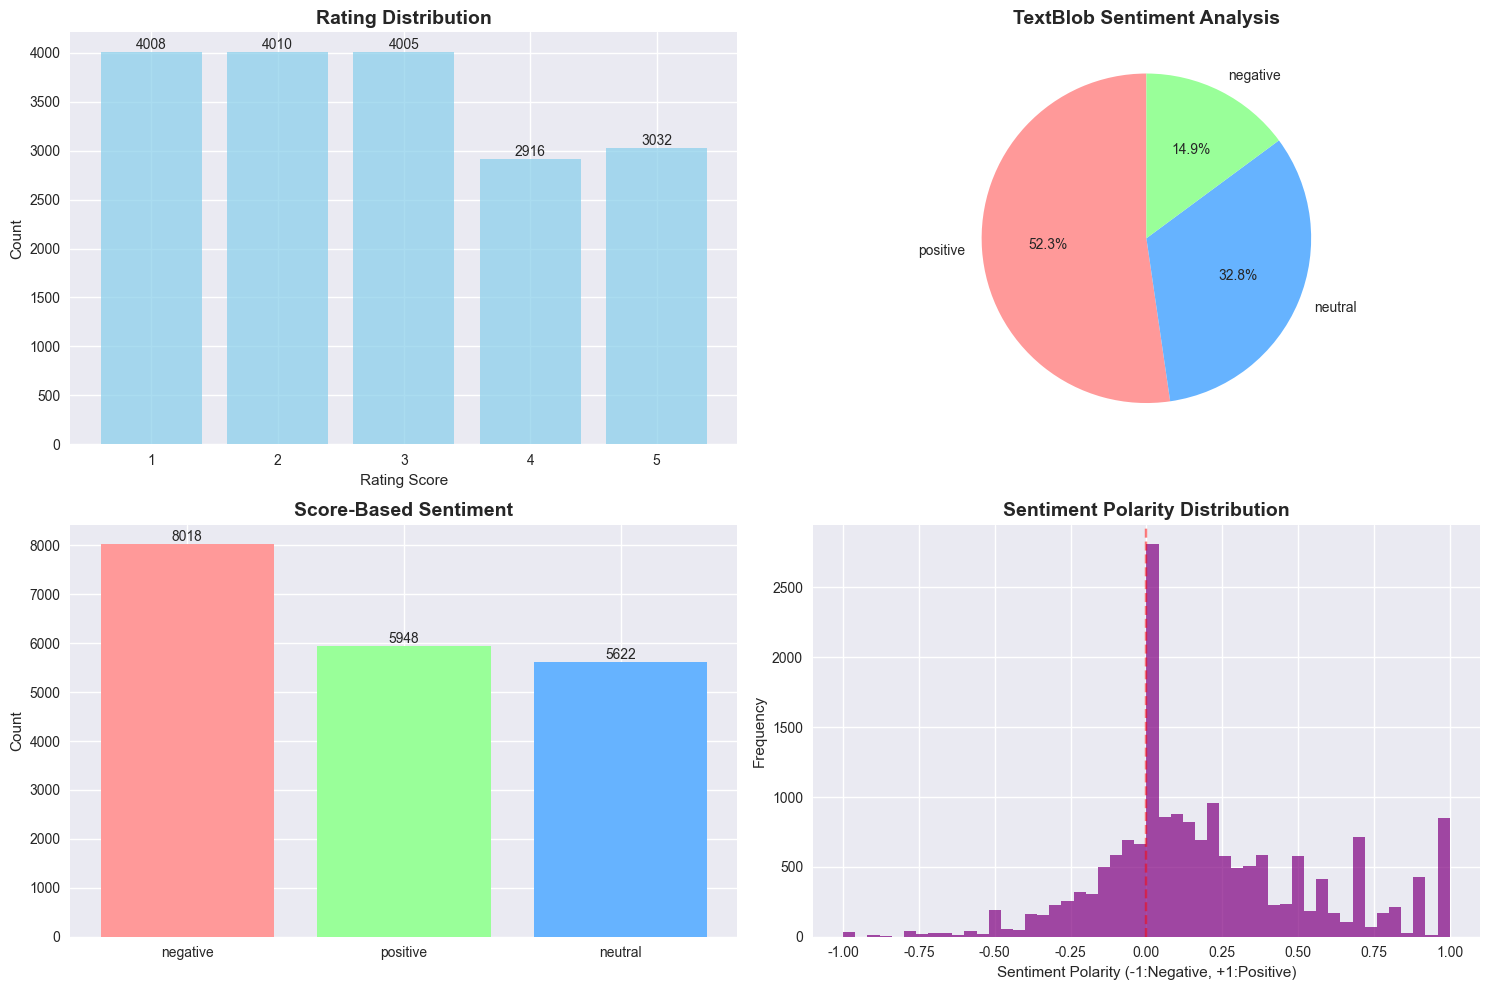

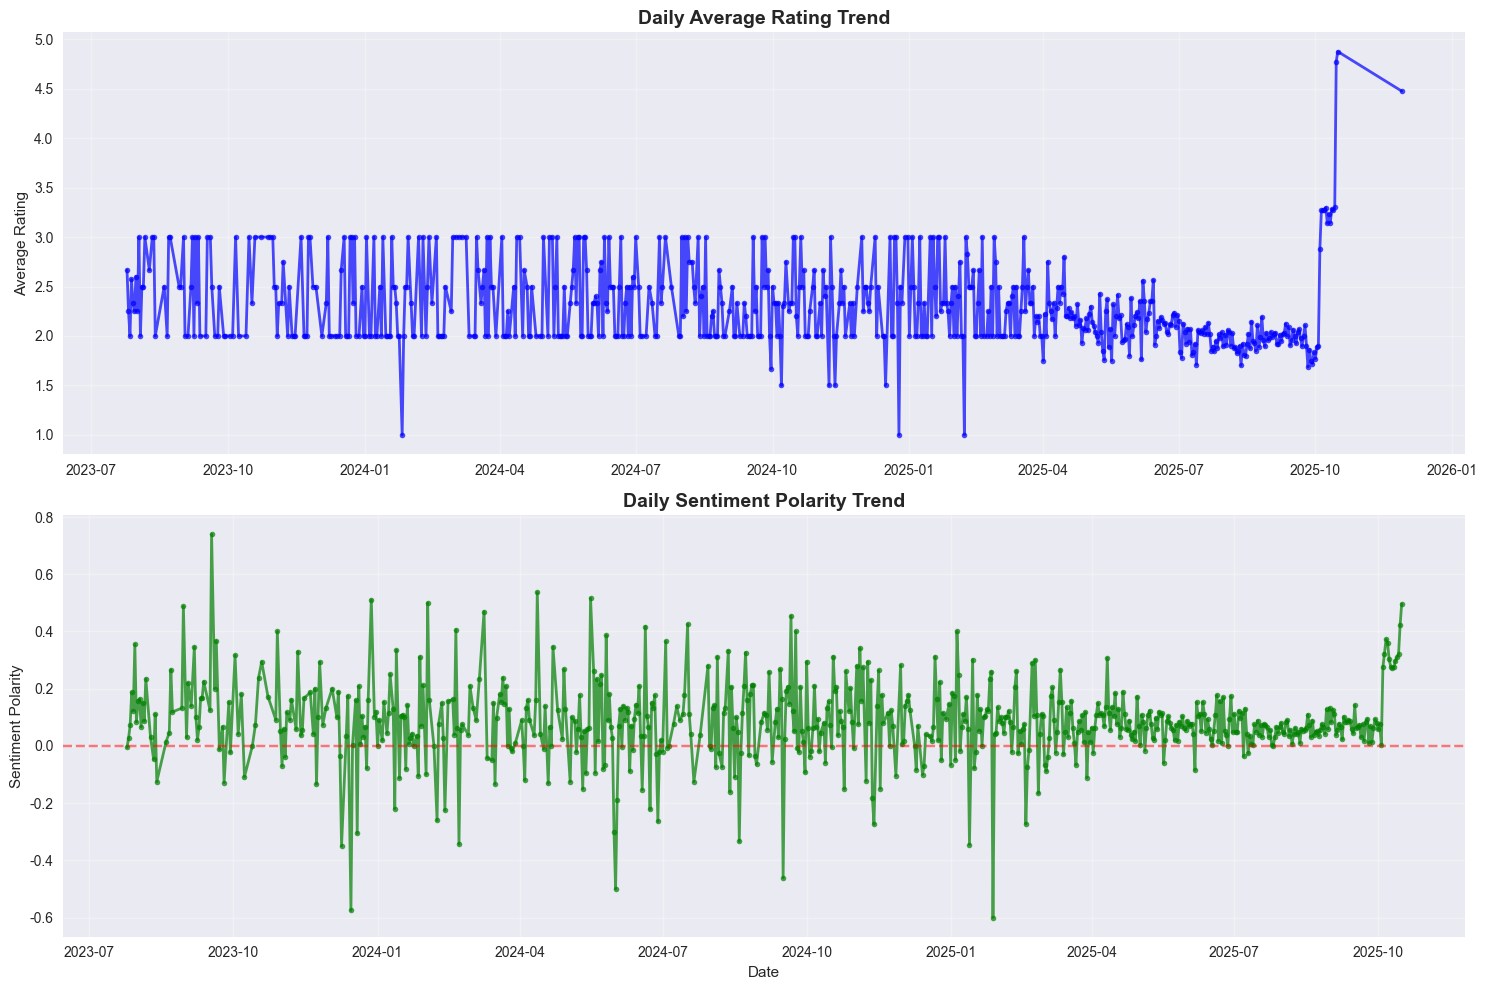

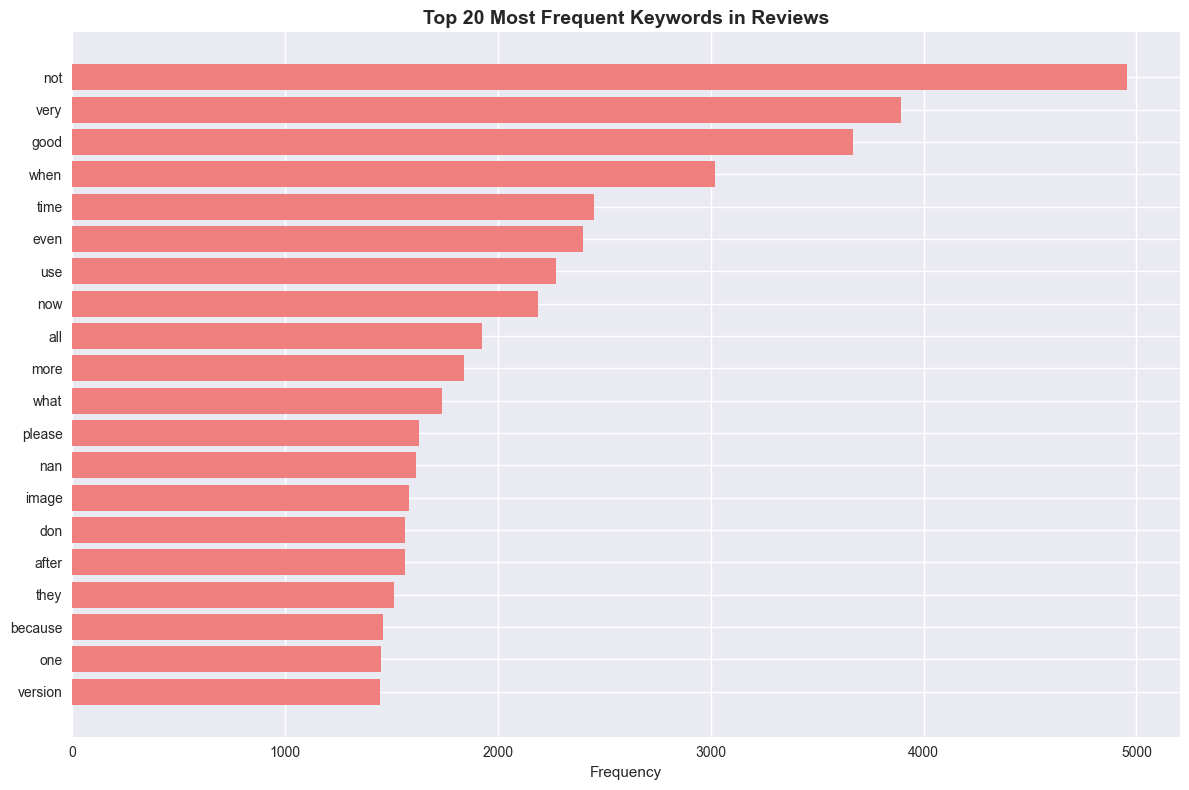

📈 ChatGPT评论情感分析报告

📊 数据库概览:
   总评论数: 20133
   平均评分: 3.01/5
   最早评论: 2023-07-25 08:31:59
   最新评论: 2025-11-28 18:52:58
   版本数量: 124

🎭 情感分析结果:
   平均情感极性: 0.198
   平均主观性: 0.499
   积极评论: 9,400 (48.0%)
   中性评论: 5,898 (30.1%)
   消极评论: 2,673 (13.6%)

🏆 代表性积极评论:
   ⭐ 评分:1.0 极性:1.000
     内容: the moment I purchase it, starts giving connection errors. while the Internet is...
   ⭐ 评分:1.0 极性:1.000
     内容: This is an excellent AI app on both mobile and my MacBook. I have purchased its ...
   ⭐ 评分:1.0 极性:1.000
     内容: Been having the best experience, until I decided to subscribe for premium. pleas...

⚠️ 代表性消极评论:
   ⭐ 评分:1.0 极性:-1.000
     内容: when swiping and than reopening - it opens the keyboard every time. I close it. ...
   ⭐ 评分:1.0 极性:-1.000
     内容: it's the worst AI app i have ever seen i wanted it to create an image saying Goo...
   ⭐ 评分:1.0 极性:-1.000
     内容: I used this app to help me write a story and it kept changing my plot, rewriting...

💡 分析建议:
   🔍 存在改进空间，建议深入分析负面反馈原因
   📋 需要关注用户

In [20]:
# 执行完整分析
print("🚀 开始ChatGPT评论情感分析")
print("="*60)

try:
    # 1. 初始化各模块
    db_manager = DatabaseManager()
    text_processor = TextProcessor()
    sentiment_analyzer = SentimentAnalyzer()
    plot_generator = PlotGenerator()
    
    # 2. 加载数据
    print("📥 正在加载数据...")
    raw_data = db_manager.load_reviews_data()
    
    if raw_data.empty:
        print("❌ 没有找到数据，请检查数据库路径")
    else:
        # 3. 获取数据库统计
        db_stats = db_manager.get_database_stats()
        print(f"📊 数据库统计: {db_stats}")
        
        # 4. 文本预处理
        print("🔄 正在预处理文本...")
        processed_data = text_processor.preprocess_dataframe(raw_data)
        
        # 5. 情感分析
        analysis_results = sentiment_analyzer.perform_sentiment_analysis(processed_data)
        
        if not analysis_results.empty:
            # 6. 生成可视化
            print("\n📈 生成可视化图表...")
            plot_generator.plot_sentiment_distribution(analysis_results)
            daily_trends = plot_generator.plot_sentiment_trends(analysis_results)
            keyword_analysis = plot_generator.plot_keyword_analysis(analysis_results, top_n=20)
            
            # 7. 生成报告
            sentiment_summary = sentiment_analyzer.get_sentiment_summary()
            extreme_reviews = sentiment_analyzer.get_extreme_reviews(n=3)
            
            generate_report_summary(db_stats, sentiment_summary, extreme_reviews)
            
            print("\n✅ 分析完成!")
        
except Exception as e:
    print(f"❌ 分析过程中出现错误: {e}")
    import traceback
    traceback.print_exc()